# MS 3313 — Comprehensive Final Exam

## Modules 1–5 (R Basics → ML Basics → ANOVA/MANOVA → Dimension Reduction → KNN → Factor & Conjoint → Clustering → Discriminant Analysis)

**Course:** MS3313  
**Final:** Cumulative — covers every technical area in the lecture notebooks.

---

### Instructions

This notebook contains **eight questions**. For each question:

- Code cells already define the **dataset name**, **input variable name (X)**, and **output / model object name** you must use. **Do not rename them — graders look for these specific names.**
- Wherever you see `# YOUR CODE HERE — delete this comment when you add your code`, replace that line with your solution.
- Wherever you see `NULL    # replace NULL with your code`, replace `NULL` with your working expression.
- After each question, an **analysis answer** markdown cell is provided. Replace `*Your answer here*` with your written interpretation (3–6 sentences).
- All datasets come from the **`mlba`** package — no external CSVs needed.
- Use `set.seed(42)` whenever a partition / random start is required (already provided).

### Required object names

| Q | Module | Dataframe | Inputs (X) / Model | Output / Result |
|---|--------|-----------|--------------------|-----------------|
| 1 | M1 — ML basics | `air.df` | `X_air`, `train.df`, `valid.df`, `fare.lm` | `Y_fare_pred`, `rmse_fare`, `mae_fare`, `mape_fare` |
| 2 | M2 — ANOVA/MANOVA | `flights.df` | `aov_dep`, `tukey_dep`, `levene_dep`, `manova_flights` | (built-in objects) |
| 3 | M3 — Dimension reduction | `uni.df` | `pca_cov`, `pca_cor` | `n_pcs_kaiser` |
| 4 | M4.0 — KNN | `tayko.df` | `tayko_train`, `tayko_valid`, `train_X_tayko`, `valid_X_tayko`, `train_y_tayko`, `valid_y_tayko` | `acc_tayko`, `best_k_tayko`, `Y_tayko_pred`, `cm_tayko` |
| 5 | M4.1a — Factor analysis | `books.df` | `X_books_norm`, `fa_books` | `kmo_books`, `bartlett_books` |
| 6 | M4.1b — Conjoint | `profiles.df` | `cj_lm`, `partworth` | `attr_importance` |
| 7 | M5.0 — Clustering | `ewa.df` | `X_ewa_norm`, `d_ewa`, `hc_ewa`, `km_ewa` | `Y_ewa_hier`, `Y_ewa_km`, `ewa_profile` |
| 8 | M5.1 — LDA | `banks.df` | `X_banks`, `Y_banks`, `lda_banks` | `Y_banks_pred`, `cm_banks`, `accuracy_banks`, `new_bank`, `pred_new_bank` |

---


## Setup: Load Required Libraries

Run this cell as-is. Do **not** modify.

In [1]:
suppressPackageStartupMessages({
  library(mlba)
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(ggplot2)
  library(caret)
  library(class)         # knn()
  library(MASS)          # lda()
  library(psych)         # KMO, cortest.bartlett, fa.parallel, fa
  library(GPArotation)
  library(car)           # leveneTest
  library(cluster)
  library(factoextra)
  library(conjoint)
  library(fastDummies)
  library(IRdisplay)
})

# dplyr::select wins after MASS is loaded
select <- dplyr::select

set.seed(42)
options(scipen = 999, digits = 4)


## Plot rendering — make charts legible

The default Jupyter R kernel often renders ggplot / `factoextra` figures
with a device that produces tiny or blurry axis text. **Every plot in this
exam must be drawn through a cairo PNG device** so axes, titles, and
legends are readable. The pattern is already provided in each plotting
cell — you only have to drop your plotting expression into the marked
spot:

```r
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 900, height = 600, res = 120,
    type = "cairo", family = "sans")

print(
  NULL    # replace NULL with your ggplot / fviz_* / plot(...) call
)

dev.off()
IRdisplay::display_png(file = tmp_file)
```

**Hints**

* For `print({ ... })` you may pass a single ggplot or `fviz_*` object.
* For base-graphics calls (e.g., `plot(hc); rect.hclust(...)`) put the
  drawing commands *between* `png(...)` and `dev.off()` — no `print()` needed.
* Keep `res = 120` and `family = "sans"` so the rendered fonts match the
  rest of the exam.


---
## Question 1 — Module 1: Multiple Linear Regression on Airfares

**Dataset:** `mlba::Airfares` (638 routes × 18 variables)

**Inputs (X):** all route variables after dropping the four ID/text columns
(`S_CODE`, `S_CITY`, `E_CODE`, `E_CITY`) and dummy-encoding the four categorical
predictors (`VACATION`, `SW`, `SLOT`, `GATE`).

**Output (Y):** `FARE` (average fare in dollars).

**Tasks:**
1. Load the data, drop the four ID columns, and dummy-encode the four categoricals → store the cleaned data in `air.df` and the predictor matrix in `X_air`
2. Partition 60% training / 40% validation with `set.seed(42)` → store in `train.df` and `valid.df`
3. Fit a multiple linear regression `FARE ~ .` on the training set → store in `fare.lm`
4. Predict on the validation set → store predictions in `Y_fare_pred`
5. Compute validation **RMSE**, **MAE**, and **MAPE** → store in `rmse_fare`, `mae_fare`, `mape_fare`
6. Identify the two predictors with the largest absolute *t*-statistic → store in `top2_air`
7. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load Data, Drop ID Columns, Dummy-Encode

Use `air.df` for the cleaned dataframe and `X_air` for the predictor matrix.

In [2]:
air.df <- mlba::Airfares
air.df <- air.df %>%
  select(-S_CODE, -S_CITY, -E_CODE, -E_CITY)
 air.df <- fastDummies::dummy_cols(air.df, 
                                  select_columns = c("VACATION", "SW", "SLOT", "GATE"), 
                                  remove_first_dummy = TRUE, 
                                  remove_selected_columns = TRUE)
X_air <- air.df %>% select(-FARE)

cat("Rows:", nrow(air.df), " Columns:", ncol(air.df), "\n")
str(air.df)


Rows: 638  Columns: 14 
'data.frame':	638 obs. of  14 variables:
 $ COUPON      : num  1 1.06 1.06 1.06 1.06 1.01 1.28 1.15 1.33 1.6 ...
 $ NEW         : int  3 3 3 3 3 3 3 3 3 2 ...
 $ HI          : num  5292 5419 9185 2657 2657 ...
 $ S_INCOME    : num  28637 26993 30124 29260 29260 ...
 $ E_INCOME    : num  21112 29838 29838 29838 29838 ...
 $ S_POP       : int  3036732 3532657 5787293 7830332 7830332 2230955 3036732 1440377 3770125 1694803 ...
 $ E_POP       : int  205711 7145897 7145897 7145897 7145897 7145897 7145897 7145897 7145897 7145897 ...
 $ DISTANCE    : int  312 576 364 612 612 309 1220 921 1249 964 ...
 $ PAX         : int  7864 8820 6452 25144 25144 13386 4625 5512 7811 4657 ...
 $ FARE        : num  64.1 174.5 207.8 85.5 85.5 ...
 $ VACATION_Yes: int  0 0 0 0 0 0 0 1 0 0 ...
 $ SW_Yes      : int  1 0 0 1 1 1 0 1 1 1 ...
 $ SLOT_Free   : int  1 1 1 0 1 1 1 1 1 1 ...
 $ GATE_Free   : int  1 1 1 1 1 1 1 1 1 1 ...


### Step 2 — 60/40 Train/Validation Partition

Store the partitions in `train.df` and `valid.df`.

In [3]:
set.seed(42)

train_idx <- caret::createDataPartition(air.df$FARE, p = 0.6, list = FALSE)
train.df  <- air.df[train_idx, ]
valid.df  <- air.df[-train_idx, ]

cat("train rows:", nrow(train.df), " valid rows:", nrow(valid.df), "\n")


train rows: 385  valid rows: 253 


### Step 3 — Fit the Multiple Linear Regression

Fit `FARE ~ .` on the training set; store the model in `fare.lm`.

In [4]:
fare.lm <- lm(FARE ~ ., data = train.df) 
summary(fare.lm)



Call:
lm(formula = FARE ~ ., data = train.df)

Residuals:
   Min     1Q Median     3Q    Max 
-99.10 -21.45  -0.78  21.77 100.49 

Coefficients:
                  Estimate    Std. Error t value             Pr(>|t|)    
(Intercept)   40.101101866  33.071580521    1.21              0.22607    
COUPON         1.997835397  15.328131274    0.13              0.89637    
NEW           -2.124524747   2.463810834   -0.86              0.38908    
HI             0.007814436   0.001286448    6.07   0.0000000030841360 ***
S_INCOME       0.001107800   0.000628728    1.76              0.07890 .  
E_INCOME       0.000896209   0.000483630    1.85              0.06466 .  
S_POP          0.000002502   0.000000824    3.04              0.00256 ** 
E_POP          0.000004296   0.000000939    4.58   0.0000064727007891 ***
DISTANCE       0.071696356   0.004461929   16.07 < 0.0000000000000002 ***
PAX           -0.000780512   0.000182810   -4.27   0.0000249106197427 ***
VACATION_Yes -35.183411484   4.647704824

### Step 4 — Predict on the Validation Set

Store the predicted fares in `Y_fare_pred`.

In [5]:
Y_fare_pred <- predict(fare.lm, newdata = valid.df)
head(Y_fare_pred)


2     11     15     20     23     26 
168.97 170.66 156.33 188.87 125.56  99.81

### Step 5 — Compute Validation RMSE, MAE, and MAPE

Store the metrics in `rmse_fare`, `mae_fare`, `mape_fare`.

In [6]:

rmse_fare <- sqrt(mean((valid.df$FARE - Y_fare_pred)^2, na.rm = TRUE))
mae_fare  <- mean(abs(valid.df$FARE - Y_fare_pred), na.rm = TRUE)
mape_fare <- mean(abs(valid.df$FARE - Y_fare_pred) / valid.df$FARE) * 100
cat(sprintf("RMSE = %.3f\nMAE  = %.3f\nMAPE = %.3f%%\n",
            rmse_fare, mae_fare, mape_fare))


RMSE = 36.166
MAE  = 28.321
MAPE = 19.903%


### Step 6 — Top 2 Most Influential Predictors (Largest |t|)

Store the two top rows of the coefficient table in `top2_air`.

In [7]:
coefficient_table <- summary(fare.lm)$coefficients
top2_air <-  coefficient_table[-1, ]
top2_air <- top2_air[order(abs(top2_air[, "t value"]), decreasing = TRUE), ]
top2_air


,Estimate,Std. Error,t value,Pr(>|t|)
DISTANCE,0.071696356,0.0044619292,16.0685,0.0000000000000000000000000000000000000000000179
SW_Yes,-40.064615716,4.8970194696,-8.1814,0.0000000000000045272243085537562997386268723384
VACATION_Yes,-35.183411484,4.6477048243,-7.5701,0.0000000000002985355721977870661141352583636409
HI,0.007814436,0.0012864483,6.0744,0.0000000030841359847407920609702418459968295550
E_POP,0.000004296,0.0000009388,4.5760,0.0000064727007890722181225021288064613855794960
GATE_Free,-22.859271620,5.1343891963,-4.4522,0.0000112605096689255570704436826279248862192617
PAX,-0.000780512,0.0001828098,-4.2695,0.0000249106197427035436870942919362903467117576
SLOT_Free,-16.957054378,5.0201548794,-3.3778,0.0008081249015022653244683104034606913046445698
S_POP,0.000002502,0.0000008238,3.0371,0.0025573700661864601745010272537683704285882413
E_INCOME,0.000896209,0.0004836296,1.8531,0.0646633859357410162305157541595690418034791946


### Question 1 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.
 
The multiple linear regression model was trained on 60% of the 638 Airfares routes and was validated using the remaining 40%. The RMSE, MAE, and MAPE were used to evaluate the accuracy of the model on the validation set. The multiple linear regression model predicted airfares on the validation set to have an RMSE of $36.17, the MAE of $28.32, and a MAPE of 19.9%, this suggests moderate predictive accuracy. Upon further analysis, it was found that the top 2 predictors with the largest t-stats are Distance with a t-value of 16.07, and SW_Yes with a t-value of -8.18. This suggests that Distance has a strong positive effect, while SW_Yes has a negative effect. 

One business takeaway that can be taken from this analysis is that one of the most important factors is whether Southwest flies a route or not because fares tend to drop significantly if they do, so they should monitor their route expansion. 



## Question 2 — Module 2: ANOVA & MANOVA on Flight Delays

**Dataset:** `mlba::FlightDelays` (2,201 flights × 13 variables)

**Tasks:**
1. Load the data, convert `CARRIER`, `DAY_WEEK`, and `Flight.Status` to factors → store in `flights.df`
2. Run a one-way **ANOVA**: does `CRS_DEP_TIME` differ across `CARRIER`? → store the model in `aov_dep`
3. Run **Tukey HSD** post-hoc on `aov_dep` → store in `tukey_dep`
4. Test homogeneity of variance with **Levene's test** (`car::leveneTest`) → store in `levene_dep`
5. Run a one-way **MANOVA**: do `CRS_DEP_TIME` and `DISTANCE` jointly differ across `DAY_WEEK`? → store in `manova_flights`; report **Pillai's trace**
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load Data and Set Factor Types

Store the cleaned dataframe in `flights.df`.

In [8]:
flights.df <- mlba::FlightDelays
flights.df <- flights.df %>%
  mutate( CARRIER = as.factor(CARRIER),
         DAY_WEEK  = as.factor(DAY_WEEK),
         Flight.Status = as.factor(Flight.Status))
cat("n =", nrow(flights.df), "  carriers =", nlevels(flights.df$CARRIER), "\n")
table(flights.df$CARRIER)


n = 2201   carriers = 8 



 CO  DH  DL  MQ  OH  RU  UA  US 
 94 551 388 295  30 408  31 404 

### Step 2 — One-Way ANOVA: `CRS_DEP_TIME ~ CARRIER`

Store the ANOVA model in `aov_dep`.

In [9]:
aov_dep <- aov(CRS_DEP_TIME ~ CARRIER, data = flights.df)
summary(aov_dep)

# Because the p-value is very small, we reject the null hypothesis and conclude that there are significant differences in departure times among the carriers. 
# This means that dep time differs across carriers. 

              Df    Sum Sq Mean Sq F value           Pr(>F)    
CARRIER        7  13475003 1925000    10.6 0.00000000000036 ***
Residuals   2193 398424008  181680                             
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

### Step 3 — Tukey HSD Post-Hoc

Store the result in `tukey_dep` and show the five smallest adjusted *p*-values.

In [10]:
tukey_dep <- TukeyHSD(aov_dep)

head(tukey_dep$CARRIER[order(tukey_dep$CARRIER[,"p adj"]), ], 5)


,diff,lwr,upr,p adj
UA-DH,-598.7,-837.4,-360.0,0.00000000006457
UA-DL,-519.4,-760.7,-278.0,0.00000000236566
US-UA,513.4,272.4,754.4,0.00000000360199
UA-CO,-569.5,-837.3,-301.7,0.00000000387473
UA-RU,-494.5,-735.4,-253.6,0.00000001596055


### Step 4 — Levene's Test for Homogeneity of Variance

Store the test result in `levene_dep`.

In [11]:
levene_dep <- leveneTest(CRS_DEP_TIME ~ CARRIER, data = flights.df)
levene_dep


,Df,F value,Pr(>F)
,<int>,<dbl>,<dbl>
group,7,19.69,0.00000000000000000000000009907
,2193,NA,NA


### Step 5 — One-Way MANOVA: `cbind(CRS_DEP_TIME, DISTANCE) ~ DAY_WEEK`

Store the MANOVA in `manova_flights` and report Pillai's trace.

In [12]:
manova_flights <- manova(cbind(CRS_DEP_TIME, DISTANCE) ~ DAY_WEEK, data = flights.df)

summary(manova_flights, test = "Pillai")
summary.aov(manova_flights) 


            Df  Pillai approx F num Df den Df Pr(>F)
DAY_WEEK     6 0.00786     1.44     12   4388   0.14
Residuals 2194                                      

 Response CRS_DEP_TIME :
              Df    Sum Sq Mean Sq F value Pr(>F)  
DAY_WEEK       6   2822921  470487    2.52  0.019 *
Residuals   2194 409076090  186452                 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

 Response DISTANCE :
              Df Sum Sq Mean Sq F value Pr(>F)
DAY_WEEK       6    382    63.7    0.36   0.91
Residuals   2194 389761   177.6               


### Question 2 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

The one-way ANOVA test found a significant difference in scheduled departure times across carriers, which suggets that each carrier has its own schedule patterns. Through the Hukkey HSD post-hoc test, 5 carriers were identified that drive these significant difference(UA-DH, UA-DL, US-UA, UA-CO, and UA-RU).However, upon conducting a Levene's test, it was found that a violation of the equal variance assumption was found, which means that the anova results should be interpreted with caution. The MANOVA test found that Pillai's trace was statistically significant, meaning that the combination of crs_dep_time and distance do not vary on daily basis. 

One business takeaway that can be taken from this analysis is that carriers tend to schedule flights at different times in a day, therefore staffing and other resources should be centered, operated and planned around these times rather than an avverage schedule.




## Question 3 — Module 3: PCA on Universities

**Dataset:** `mlba::Universities` (1,302 universities × 20 variables)

**Inputs (X):** the 17 numeric metrics — drop `College.Name`, `State`, and the
binary public/private flag, then drop rows with any `NA`.

**Tasks:**
1. Load the data, drop the three non-numeric columns, drop rows with any `NA` → store in `uni.df`
2. Run PCA on the **covariance** matrix (raw scale) → store in `pca_cov`
3. Run PCA on the **correlation** matrix (`scale. = TRUE`) → store in `pca_cor`
4. Apply the **Kaiser rule** (eigenvalue ≥ 1) on `pca_cor` → store the count in `n_pcs_kaiser`; report the cumulative variance explained
5. Plot the **scree plot** and the **PC1–PC2 biplot** of `pca_cor`
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load and Clean the Data

Store the cleaned numeric dataframe in `uni.df`.

In [13]:
uni.df <- mlba::Universities
uni.df <- uni.df %>%
select(-1, -2, -3) %>%
 na.omit()
 summary(uni.df)
cat("n =", nrow(uni.df), "  p =", ncol(uni.df), "\n")


 X..appli..rec.d X..appl..accepted X..new.stud..enrolled
 Min.   :   77   Min.   :   61     Min.   :  27         
 1st Qu.:  802   1st Qu.:  636     1st Qu.: 264         
 Median : 1646   Median : 1227     Median : 443         
 Mean   : 3147   Mean   : 2063     Mean   : 781         
 3rd Qu.: 3862   3rd Qu.: 2456     3rd Qu.: 896         
 Max.   :48094   Max.   :26330     Max.   :6392         
 X..new.stud..from.top.10. X..new.stud..from.top.25. X..FT.undergrad
 Min.   : 1                Min.   :  9.0             Min.   :  249  
 1st Qu.:15                1st Qu.: 40.0             1st Qu.: 1018  
 Median :23                Median : 54.0             Median : 1715  
 Mean   :28                Mean   : 55.7             Mean   : 3563  
 3rd Qu.:36                3rd Qu.: 69.0             3rd Qu.: 4056  
 Max.   :96                Max.   :100.0             Max.   :31643  
 X..PT.undergrad   in.state.tuition out.of.state.tuition      room     
 Min.   :    1.0   Min.   :  608    Min.   : 1

n = 471   p = 17 


### Step 2 — PCA on the Covariance Matrix

Store in `pca_cov`. (Use `prcomp` with `scale. = FALSE`.)

In [14]:
pca_cov <- prcomp(uni.df, center = TRUE, scale. = FALSE)
round(summary(pca_cov)$importance[, 1:5], 4)


,PC1,PC2,PC3,PC4,PC5
Standard deviation,7430.9140,5987.9890,1854.6412,1192.5293,967.4279
Proportion of Variance,0.5614,0.3645,0.0350,0.0145,0.0095
Cumulative Proportion,0.5614,0.9259,0.9609,0.9753,0.9848


### Step 3 — PCA on the Correlation Matrix (Standardized)

Store in `pca_cor`. (Use `prcomp` with `scale. = TRUE`.)

In [15]:
pca_cor <- prcomp(uni.df, center = TRUE, scale. = TRUE)
round(summary(pca_cor)$importance[, 1:6], 4)


,PC1,PC2,PC3,PC4,PC5,PC6
Standard deviation,2.2749,2.1426,1.0984,1.0325,0.9760,0.8728
Proportion of Variance,0.3044,0.2700,0.0710,0.0627,0.0560,0.0448
Cumulative Proportion,0.3044,0.5745,0.6454,0.7081,0.7642,0.8090


### Step 4 — Kaiser Rule

Store the number of components retained in `n_pcs_kaiser`.

In [16]:
# YOUR CODE HERE — delete this comment when you add your code
# Required object: n_pcs_kaiser

summary(pca_cor)
n_pcs_kaiser <- 4

eig <- pca_cor$sdev^2
n_pcs_kaiser <- sum(eig >= 1)
cat("Kaiser keeps", n_pcs_kaiser, "PCs\n")
cat("Cumulative variance explained =",
 round(sum(eig[seq_len(n_pcs_kaiser)]) / sum(eig), 3), "\n")


Importance of components:
                         PC1   PC2   PC3    PC4   PC5    PC6   PC7    PC8
Standard deviation     2.275 2.143 1.098 1.0325 0.976 0.8728 0.803 0.7728
Proportion of Variance 0.304 0.270 0.071 0.0627 0.056 0.0448 0.038 0.0351
Cumulative Proportion  0.304 0.574 0.645 0.7081 0.764 0.8090 0.847 0.8821
                          PC9   PC10   PC11   PC12   PC13    PC14    PC15
Standard deviation     0.7032 0.6622 0.6279 0.5497 0.4383 0.30389 0.20002
Proportion of Variance 0.0291 0.0258 0.0232 0.0178 0.0113 0.00543 0.00235
Cumulative Proportion  0.9112 0.9369 0.9601 0.9779 0.9892 0.99464 0.99700
                          PC16    PC17
Standard deviation     0.17428 0.14388
Proportion of Variance 0.00179 0.00122
Cumulative Proportion  0.99878 1.00000

Kaiser keeps 4 PCs
Cumulative variance explained = 0.708 


### Step 5 — Scree Plot and PC1–PC2 Biplot

agg_record_1423213877 
                    2

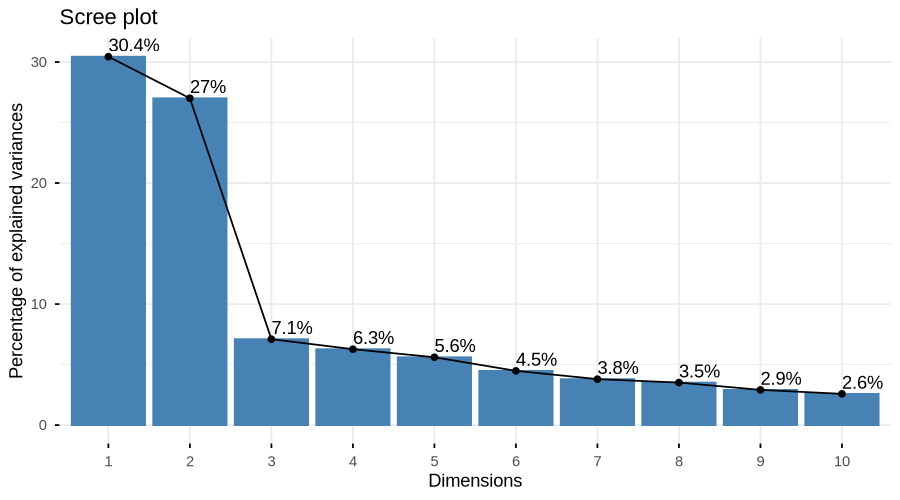

In [17]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 900, height = 500, res = 120,
    type = "cairo", family = "sans")
    
print(factoextra::fviz_eig(pca_cor, addlabels = TRUE))

dev.off()
IRdisplay::display_png(file = tmp_file)


agg_record_1521153790 
                    2

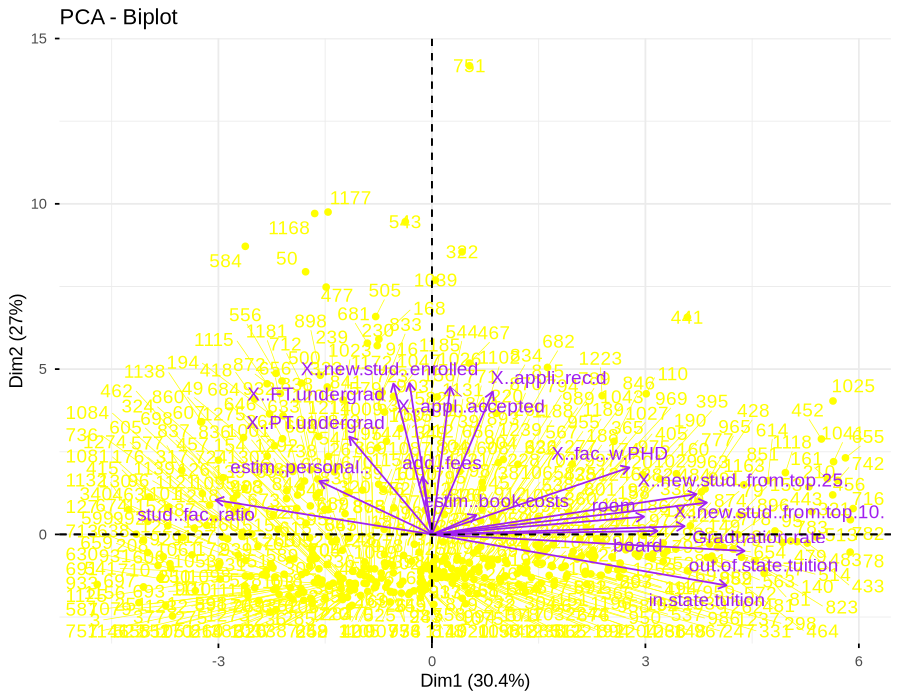

In [18]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 900, height = 700, res = 120,
    type = "cairo", family = "sans")

print(factoextra::fviz_pca_biplot(pca_cor, repel = TRUE, col.var = "purple", col.ind = "yellow"))

dev.off()
IRdisplay::display_png(file = tmp_file)


### Question 3 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

The PCA results found that there are four components that should be retained according to the Kaiser Rule, which explains 70.8% of the total vairiance in the dataset. The Scree Plot can confirm this because it shows a distinct "elbow" where the captured variance begins to level off. From the Biplot, it can be said that PC1 is heavily influenced by SAT scores, while PC2 captures the costs and spending.

One business takeaway from this analysis is that universities can use these components to identifty what they share with other universities. This can help universities stand out by focusing on other variables that are not being taken into consideration in this market. 


## Question 4 — Module 4.0: K-Nearest Neighbors on Tayko

**Dataset:** `mlba::Tayko` (2,000 catalog customers × 25 variables)

**Inputs (X):** all variables except `sequence_number` and `Spending`
(`Spending` is target leakage: `Spending > 0` ⇒ `Purchase = 1`).

**Output (Y):** `Purchase` as a factor with levels `c("No", "Yes")`.

**Tasks:**
1. Load the data, drop `sequence_number` and `Spending`, factor `Purchase` → store in `tayko.df`
2. Partition 60/40 with `set.seed(42)` → store in `tayko_train` and `tayko_valid`
3. Standardize using **training-set statistics only** (`caret::preProcess`) → store in `train_X_tayko`, `valid_X_tayko`, `train_y_tayko`, `valid_y_tayko`
4. Tune `k` over `1:15` using `class::knn` and validation accuracy → store the table in `acc_tayko` and the best `k` in `best_k_tayko`
5. Refit at `k = best_k_tayko`, store predictions in `Y_tayko_pred` and the confusion matrix in `cm_tayko`
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load and Clean the Data

Store in `tayko.df`. Make `Purchase` a factor with levels `c("No", "Yes")`.

In [19]:
tayko.df <- mlba::Tayko 

tayko.df <- tayko.df %>% 
select(-sequence_number, -Spending) %>%
mutate(Purchase = factor(Purchase, levels = c(0, 1), labels = c("No", "Yes")))

cat("Rows:", nrow(tayko.df), "  Columns:", ncol(tayko.df), "\n")
table(tayko.df$Purchase)


Rows: 2000   Columns: 23 



  No  Yes 
1000 1000 

### Step 2 — 60/40 Partition

Store in `tayko_train` and `tayko_valid`.

In [20]:
set.seed(42)

train_idx    <- sample(nrow(tayko.df), size = 0.6 * nrow(tayko.df))
tayko_train  <- tayko.df[train_idx, ]
tayko_valid  <- tayko.df[-train_idx, ]

cat("train:", nrow(tayko_train), "  valid:", nrow(tayko_valid), "\n")


train: 1200   valid: 800 


### Step 3 — Standardize Predictors (Training Stats Only)

Store predictor matrices in `train_X_tayko`, `valid_X_tayko` and labels in
`train_y_tayko`, `valid_y_tayko`. Use `caret::preProcess(method = c("center","scale"))`.

In [21]:
# YOUR CODE HERE — delete this comment when you add your code
# Required objects: pp_tayko, train_X_tayko, valid_X_tayko, train_y_tayko, valid_y_tayko

pp_tayko      <- caret::preProcess(tayko_train %>% select(-Purchase),
 method = c("center", "scale"))
train_X_tayko <- predict(pp_tayko, tayko_train %>% select(-Purchase))
valid_X_tayko <- predict(pp_tayko, tayko_valid %>% select(-Purchase))
train_y_tayko <- tayko_train$Purchase
valid_y_tayko <- tayko_valid$Purchase

cat("Train means (should be ~0):\n"); print(round(colMeans(train_X_tayko), 3))


Train means (should be ~0):
                  US             source_a             source_c 
                   0                    0                    0 
            source_b             source_d             source_e 
                   0                    0                    0 
            source_m             source_o             source_h 
                   0                    0                    0 
            source_r             source_s             source_t 
                   0                    0                    0 
            source_u             source_p             source_x 
                   0                    0                    0 
            source_w                 Freq last_update_days_ago 
                   0                    0                    0 
X1st_update_days_ago            Web.order          Gender.male 
                   0                    0                    0 
      Address_is_res 
                   0 


### Step 4 — Tune `k` over 1..15

Store the per-k accuracy table in `acc_tayko` and the best `k` in `best_k_tayko`.

In [22]:
# YOUR CODE HERE — delete this comment when you add your code
# Required objects: acc_tayko, best_k_tayko

acc_tayko    <- data.frame(k = 1:15, accuracy = sapply(1:15, function(k) {
  knn_pred <- class::knn(train = train_X_tayko,
  test = valid_X_tayko, 
  cl =train_y_tayko, 
  k = k)
  mean(knn_pred == valid_y_tayko)
}))
best_k_tayko <- acc_tayko$k[which.max(acc_tayko$accuracy)]

print(acc_tayko)
cat("Best k =", best_k_tayko,
    "  validation accuracy =", round(max(acc_tayko$accuracy), 4), "\n")


    k accuracy
1   1   0.7425
2   2   0.7388
3   3   0.7575
4   4   0.7512
5   5   0.7438
6   6   0.7575
7   7   0.7525
8   8   0.7512
9   9   0.7425
10 10   0.7375
11 11   0.7425
12 12   0.7412
13 13   0.7438
14 14   0.7400
15 15   0.7450
Best k = 3   validation accuracy = 0.7575 


### Step 5 — Final Confusion Matrix at `best_k_tayko`

Store predictions in `Y_tayko_pred` and the `caret::confusionMatrix` object in `cm_tayko`.

In [23]:
# YOUR CODE HERE — delete this comment when you add your code
# Required objects: Y_tayko_pred, cm_tayko

Y_tayko_pred <- class::knn(train = train_X_tayko,
  test = valid_X_tayko, 
  cl =train_y_tayko, 
  k = best_k_tayko)
cm_tayko   <- caret::confusionMatrix(Y_tayko_pred, valid_y_tayko, positive = "Yes")

cm_tayko


Confusion Matrix and Statistics

          Reference
Prediction  No Yes
       No  314  98
       Yes  96 292
                                             
               Accuracy : 0.757              
                 95% CI : (0.726, 0.787)     
    No Information Rate : 0.512              
    P-Value [Acc > NIR] : <0.0000000000000002
                                             
                  Kappa : 0.515              
                                             
 Mcnemar's Test P-Value : 0.943              
                                             
            Sensitivity : 0.749              
            Specificity : 0.766              
         Pos Pred Value : 0.753              
         Neg Pred Value : 0.762              
             Prevalence : 0.487              
         Detection Rate : 0.365              
   Detection Prevalence : 0.485              
      Balanced Accuracy : 0.757              
                                             
       'Positive

### Question 4 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

In this analysis, the KNN model was tuned by testing values from 1 to 15 and it was found that the optimal k was achieved at k =3 with a validation accuracy of 75.6%. The confusion matrix demonstrates a balanced performance between sensitivity being 74.6%, and specificity being 76.6%. 

After conducting a further analysis, one business takeaway that can be taken from this is that Tayko can potentially cut their costs in half. This can be achieved by targeting only those that the model may flag as likely customers because Tayko is now able to correctly identify 3 out of 4 potential buyers. This can greatly help them by cutting costs such as mailing costs, while maintaing most of its sales. 


## Question 5 — Module 4.1a: Factor Analysis on Charles Book Club

**Dataset:** `mlba::CharlesBookClub` (4,000 members × 24 variables)

**Inputs (X):** the 8 book-category purchase counts —
`ChildBks, YouthBks, CookBks, DoItYBks, RefBks, ArtBks, GeogBks, ItalCook`.

**Tasks:**
1. Subset to the 8 book-category columns → store in `books.df`
2. Standardize with `scale()` → store in `X_books_norm`
3. Verify factorability: **KMO** (`psych::KMO`) → store in `kmo_books`; **Bartlett's sphericity test** (`psych::cortest.bartlett`) → store in `bartlett_books`
4. Run a parallel-analysis scree plot (`fa.parallel`) to choose the number of factors
5. Run an **EFA with varimax rotation** (`psych::fa`) at `nfactors = 2` → store in `fa_books`; print loadings ≥ 0.30
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 & 2 — Subset and Standardize

Store the 8-column dataframe in `books.df` and the standardized matrix in `X_books_norm`.

In [24]:

book_vars <- c("ChildBks","YouthBks","CookBks","DoItYBks",
               "RefBks","ArtBks","GeogBks","ItalCook")

books.df     <- mlba::CharlesBookClub
books.df <- books.df %>% select(all_of(book_vars))
X_books_norm <- scale(books.df)

cat("n =", nrow(books.df), " variables =", ncol(books.df), "\n")


n = 4000  variables = 8 


### Step 3 — KMO and Bartlett's Sphericity Test

Store in `kmo_books` and `bartlett_books`.

In [25]:
kmo_books      <- psych::KMO(cor(X_books_norm)) 
bartlett_books <- psych::cortest.bartlett(cor(X_books_norm))  

cat("Overall KMO:", round(kmo_books$MSA, 3), "\n")
print(bartlett_books)


Warning message in psych::cortest.bartlett(cor(X_books_norm)):
“n not specified, 100 used”


Overall KMO: 0.795 
$chisq
[1] 75.74

$p.value
[1] 0.000002832

$df
[1] 28



### Step 4 — Parallel Analysis to Decide the Number of Factors

Parallel analysis suggests that the number of factors =  4  and the number of components =  NA 
Call: fa.parallel(x = X_books_norm, fa = "fa", main = "Parallel Analysis Scree Plot")
Parallel analysis suggests that the number of factors =  4  and the number of components =  NA 

 Eigen Values of 

 eigen values of factors
[1]  1.68  0.09  0.05  0.04  0.00 -0.01 -0.06 -0.12

 eigen values of simulated factors
[1]  0.47  0.05  0.03  0.02  0.00 -0.02 -0.03 -0.05

 eigen values of components 
[1] 2.39 1.01 0.96 0.86 0.79 0.75 0.66 0.58

 eigen values of simulated components
[1] NA


agg_record_1886082817 
                    2

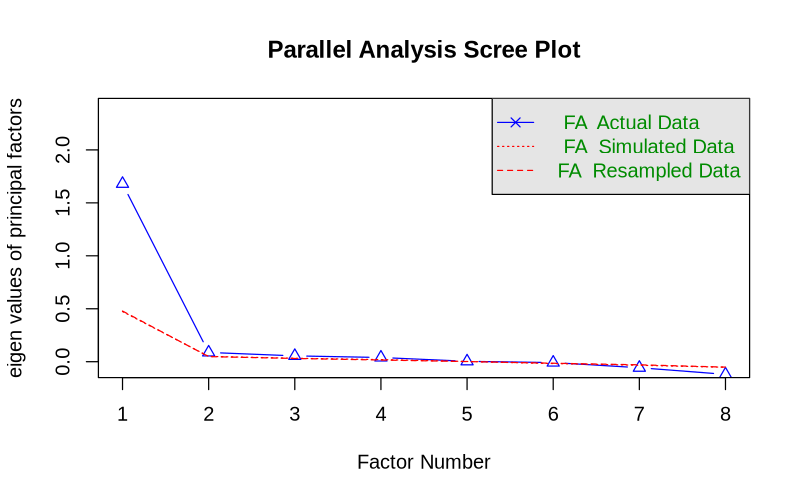

In [26]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 800, height = 500, res = 120,
    type = "cairo", family = "sans")


print(
  fa.parallel(X_books_norm, fa = "fa", main = "Parallel Analysis Scree Plot"    
))

dev.off()
IRdisplay::display_png(file = tmp_file)


### Step 5 — EFA with Varimax Rotation, `nfactors = 2`

Store the result in `fa_books`. Print loadings with `cutoff = 0.30, sort = TRUE`.

In [27]:
fa_books <- psych::fa(X_books_norm, nfactors = 2, rotate = "varimax", fm = "pa")

print(fa_books$loadings, cutoff = 0.30, sort = TRUE)
fa_books$Vaccounted


maximum iteration exceeded




Loadings:
         PA1   PA2  
ChildBks 0.608      
CookBks  0.675      
ArtBks         0.584
YouthBks 0.474      
DoItYBks 0.488      
RefBks   0.411      
GeogBks  0.357      
ItalCook            

                 PA1   PA2
SS loadings    1.618 0.406
Proportion Var 0.202 0.051
Cumulative Var 0.202 0.253


,PA1,PA2
SS loadings,1.6178,0.4056
Proportion Var,0.2022,0.0507
Cumulative Var,0.2022,0.2529
Proportion Explained,0.7995,0.2005
Cumulative Proportion,0.7995,1.0000


### Question 5 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

The KMO statistic and the Bartlett's test was significant which indicates that the correlation matrix is appropriate for factor extraction. Parallel analysis suggested 4 factors, but EFA was used to conduct a 2-factor varmix to produce a more simple mode. These 2 factors demonstrate the primary book purchasing behaviors in the Charles Book Club dataset.Factor 1 can be seen heavily relying on children's books, cookbks,youthbks, doitbks, refbks, and geogbks. While factor 2 laods ArtBks, suggesting that there's a certain buyer segment interested in fine arts. 

One business takeaway that can be taken from this analysis is that Charles Book Club should focus on ArtBk buyers and focus on targeting this group through culture promotions. 


## Question 6 — Module 4.1b: Conjoint Analysis (Streaming Service)

A streaming service tests three attributes:
`Price` (\$8 / \$12 / \$16), `Resolution` (HD / 4K), `Ads` (Yes / No).
A focus-group respondent rated each of the 12 profiles on a 1 (worst) – 9 (best)
scale.

**Tasks:**
1. Build the 3 × 2 × 2 = 12 profile design dataframe (with the ratings vector below) → store in `profiles.df`
2. Estimate part-worth utilities by fitting `Rating ~ Price + Resolution + Ads` → store in `cj_lm`
3. Compute the part-worths (level mean − grand mean) → store in `partworth` (a named list, one element per attribute)
4. Compute attribute importance % (range / sum of ranges × 100) → store in `attr_importance`
5. Identify the **best** and **worst** predicted profiles → store in `best_profile` and `worst_profile`
6. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Build the Profile Design and Add Ratings

Store in `profiles.df`. Use the ratings vector exactly as provided.

In [28]:
# YOUR CODE HERE — delete this comment when you add your code
# Required object: profiles.df

profiles.df <- expand.grid(
  Price      = factor(c("$8","$12","$16"), levels = c("$8","$12","$16")),
  Resolution = factor(c("HD","4K")),
  Ads        = factor(c("Yes","No"))
)
profiles.df$Rating <- c(7, 5, 3,  9, 6,
                        8, 5, 2,  9, 7,
                        6, 4)        # 12 ratings provided

profiles.df


Price,Resolution,Ads,Rating
<fct>,<fct>,<fct>,<dbl>
$8,HD,Yes,7
$12,HD,Yes,5
$16,HD,Yes,3
$8,4K,Yes,9
$12,4K,Yes,6
$16,4K,Yes,8
$8,HD,No,5
$12,HD,No,2
$16,HD,No,9


### Step 2 — Linear Regression for Part-Worths

Store the model in `cj_lm`.

In [29]:
cj_lm <- lm(Rating ~ Price + Resolution + Ads, data = profiles.df)

summary(cj_lm)



Call:
lm(formula = Rating ~ Price + Resolution + Ads, data = profiles.df)

Residuals:
   Min     1Q Median     3Q    Max 
-2.667 -1.021  0.208  0.833  4.167 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)   
(Intercept)     7.333      1.462    5.02   0.0015 **
Price$12       -2.250      1.602   -1.40   0.2029   
Price$16       -1.000      1.602   -0.62   0.5522   
ResolutionHD   -1.500      1.308   -1.15   0.2891   
AdsYes          0.833      1.308    0.64   0.5443   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 2.27 on 7 degrees of freedom
Multiple R-squared:  0.346,	Adjusted R-squared:  -0.0277 
F-statistic: 0.926 on 4 and 7 DF,  p-value: 0.5


### Step 3 — Compute Part-Worths

Store in `partworth` as a named list (one element per attribute) where each
element is a vector of (level mean − grand mean).

In [30]:
grand_mean <- mean(profiles.df$Rating)

partworth <- list(
    Price = tapply(profiles.df$Rating, profiles.df$Price, mean) - grand_mean,
    Resolution = tapply(profiles.df$Rating, profiles.df$Resolution, mean) - grand_mean,
    Ads = tapply(profiles.df$Rating, profiles.df$Ads, mean) - grand_mean
)

partworth$Price      <- partworth$Price     
partworth$Resolution <- partworth$Resolution
partworth$Ads        <- partworth$Ads

partworth


$Price
      $8      $12      $16 
 1.08333 -1.16667  0.08333 

$Resolution
   4K    HD 
 0.75 -0.75 

$Ads
     No     Yes 
-0.4167  0.4167

### Step 4 — Attribute Importance (%)

Store in `attr_importance` (a named numeric vector summing to ~100).

In [31]:

attr_importance <- sapply(partworth, function(x) diff(range(x)))
attr_importance <- 100 * attr_importance / sum(attr_importance)
round(attr_importance, 1)


Price Resolution        Ads 
      49.1       32.7       18.2

### Step 5 — Best and Worst Predicted Profiles

Store in `best_profile` and `worst_profile`.

In [32]:

profiles.df$Pred <- predict(cj_lm)
best_profile  <- profiles.df[which.max(profiles.df$Pred), ]
worst_profile <- profiles.df[which.min(profiles.df$Pred), ]

cat("BEST predicted profile:\n");  print(best_profile)
cat("\nWORST predicted profile:\n"); print(worst_profile)


BEST predicted profile:
  Price Resolution Ads Rating  Pred
4    $8         4K Yes      9 8.167

WORST predicted profile:
  Price Resolution Ads Rating  Pred
8   $12         HD  No      2 3.583


### Question 6 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

The conjoint analysis demonstrate that Price(49.1%) is the most important attribute, while Resolution(32.7%) is the second most important attribute and Ads(18.2%) having little to no influence in the ratings. The model suggested that the best predicted profile as $8 price point with 4k resolution and ads with a rating of 8.17, however the worst profile is $12 HD option with no ads and a rating of 3.58.

One business takeaway from can be taken from this analysis is that streaming services should focus on keeping prices low, around $8, as it's demonstrated that users tend to watch ads for a better price and higher resolultion. 


## Question 7 — Module 5.0: Cluster Analysis on EastWestAirlines

**Dataset:** `mlba::EastWestAirlinesCluster` (3,999 frequent-flyers × 12 variables)

**Inputs (X):** the 10 behavioral variables — drop `ID.` and `Award.`.

**Tasks:**
1. Load the data, drop `ID.` and `Award.` → store in `ewa.df`; standardize → store in `X_ewa_norm`
2. Compute the Euclidean distance matrix → store in `d_ewa`
3. **Hierarchical clustering with Ward's linkage** (`method = "ward.D2"`) → store in `hc_ewa`; cut at `k = 4` → store labels in `Y_ewa_hier`
4. **K-means** with `centers = 4`, `nstart = 25`, `set.seed(42)` → store in `km_ewa`; store labels in `Y_ewa_km`
5. Cross-tabulate hierarchical vs k-means cluster labels
6. Profile the k-means clusters on the **original (unstandardized)** scale → store the table in `ewa_profile`
7. Plot the k-means cluster visualization (`fviz_cluster`)
8. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load, Drop ID/Award, Standardize

Store the cleaned dataframe in `ewa.df` and the standardized matrix in `X_ewa_norm`.

In [33]:

ewa.df      <- mlba::EastWestAirlinesCluster %>%
  select(-ID., -Award.)
X_ewa_norm  <- scale(ewa.df)

cat("n =", nrow(ewa.df), " p =", ncol(ewa.df), "\n")


n = 3999  p = 10 


### Step 2 — Euclidean Distance Matrix

Store in `d_ewa`.

In [34]:

d_ewa <-dist(X_ewa_norm, method = "euclidean")


### Step 3 — Hierarchical Clustering (Ward) and Cut at k = 4

Store the hclust object in `hc_ewa` and the cluster labels in `Y_ewa_hier`.

In [35]:
hc_ewa     <- hclust(d_ewa, method = "ward.D2")
Y_ewa_hier <- cutree(hc_ewa, k = 4)

table(Y_ewa_hier)


Y_ewa_hier
   1    2    3    4 
2850 1010   43   96 

### Step 3b — Plot the Ward Dendrogram (with k = 4 boxes)

Use the cairo-PNG wrapper. Draw `plot(hc_ewa, labels = FALSE, ...)` and
overlay `rect.hclust(hc_ewa, k = 4, border = "red")`.

agg_record_1361106105 
                    2

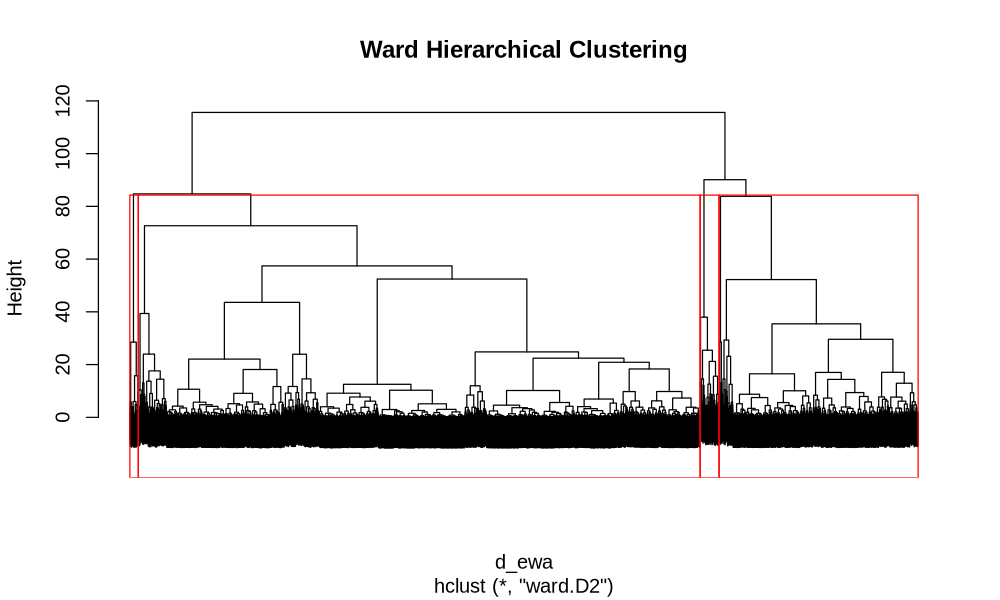

In [36]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 1000, height = 600, res = 120,
    type = "cairo", family = "sans")

plot(hc_ewa, labels = FALSE, main = "Ward Hierarchical Clustering")
rect.hclust(hc_ewa, k = 4, border = "red")

dev.off()
IRdisplay::display_png(file = tmp_file)


### Step 4 — K-Means (k = 4)

Store the kmeans object in `km_ewa` and the labels in `Y_ewa_km`.

In [37]:
set.seed(42)

km_ewa   <- kmeans(X_ewa_norm, centers = 4, nstart = 25)
Y_ewa_km <- km_ewa$cluster

table(Y_ewa_km)


Y_ewa_km
   1    2    3    4 
  15 2479  160 1345 

### Step 5 — Cross-Tabulate Hierarchical vs K-Means

In [38]:
table(Y_ewa_hier, Y_ewa_km)


          Y_ewa_km
Y_ewa_hier    1    2    3    4
         1    0 2424   58  368
         2   15   17    6  972
         3    0   37    4    2
         4    0    1   92    3

### Step 6 — Cluster Profile (Original Scale)

Store the per-cluster mean table in `ewa_profile`.

In [39]:
ewa_profile <- ewa.df %>%
  mutate(Cluster = Y_ewa_km) %>%
  group_by(Cluster) %>%
  summarise(across(everything(), mean)) %>%
  as.data.frame()

ewa_profile



Cluster,Balance,Qual_miles,cc1_miles,cc2_miles,cc3_miles,Bonus_miles,Bonus_trans,Flight_miles_12mo,Flight_trans_12,Days_since_enroll
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,138061,78.8,3.467,1.000,4.067,93928,28.067,506.7,1.6000,4614
2,42759,105.0,1.162,1.020,1.000,4281,6.642,212.9,0.6482,3699
3,193027,802.8,2.181,1.038,1.000,31888,27.431,5455.5,16.0688,4712
4,115522,138.6,3.683,1.001,1.001,38244,18.677,320.8,0.9599,4817


### Step 7 — K-Means Cluster Visualization

agg_record_1944488234 
                    2

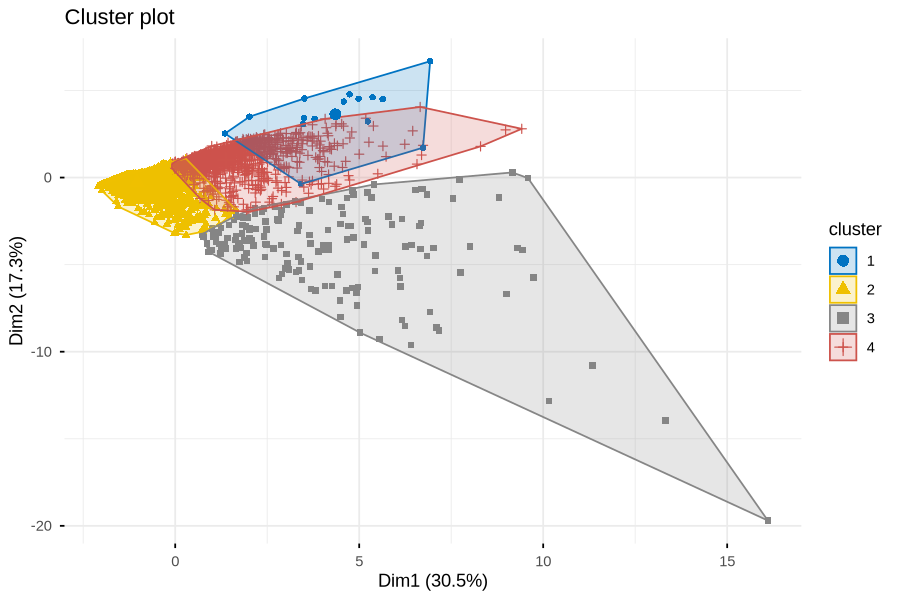

In [40]:
tmp_file <- tempfile(fileext = ".png")
png(tmp_file, width = 900, height = 600, res = 120,
    type = "cairo", family = "sans")

print(
  factoextra::fviz_cluster(
    km_ewa,
    data = X_ewa_norm,
    geom = "point",
    ellipse.type = "convex",
    repel = TRUE,
    palette = "jco",
    ggtheme = ggplot2::theme_minimal()
  )
)
dev.off()
IRdisplay::display_png(file = tmp_file)


### Question 7 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

The cluster analysis on the EastWestAirlines identified 4 distinct segments of frequent flyers that contain both hierarchical and k-mean results that are consistent. Cluster 3 can identified as "Elite flyers" as they have the highest mileage and flight frequency among the clusters, while Cluster 2 can be labeled as "Moderate flyers" as they have the lowest engagement across all clusters.After conducting a cross-tabulation, it is confimred that both segments have a high level of agreement and are both stable. 

One business takeaway that can be taken from this analysis is that airline businesses should stray away from a "one size fits all" approach and instead focus on implementing a rewards program in place. For example, airline businesses can offere high value rewards for those in Cluster 3 (elite), and target mile promotions to those in Cluster 2(moderate) to encourage them to travel more frequent. 


## Question 8 — Module 5.1: Linear Discriminant Analysis on Banks

**Dataset:** `mlba::Banks` (20 banks × 5 variables)

**Inputs (X):** `TotCap.Assets`, `TotExp.Assets`, `TotLns.Lses.Assets`.

**Output (Y):** `Financial.Condition` recoded as a factor with labels
`c("Strong", "Weak")` (levels `0 = Strong, 1 = Weak`).

**Tasks:**
1. Load the data, drop `Obs`, recode `Financial.Condition` to a factor with labels `c("Strong","Weak")` → store in `banks.df`; create `X_banks` (3 predictors) and `Y_banks` (target factor)
2. Fit an **LDA**: `Financial.Condition ~ .` → store in `lda_banks`
3. Predict on the full data (n = 20 is too small to hold out) → store predicted classes in `Y_banks_pred`, the `caret::confusionMatrix` in `cm_banks`, and the overall accuracy in `accuracy_banks`
4. Predict the financial condition of a new bank with `TotCap.Assets = 8.0`, `TotExp.Assets = 0.11`, `TotLns.Lses.Assets = 0.55` → store the new observation in `new_bank` and the prediction in `pred_new_bank`
5. Provide a written interpretation in the **markdown answer cell** at the end of this question

### Step 1 — Load and Prepare Data

Store the cleaned dataframe in `banks.df`, predictors in `X_banks`, target in `Y_banks`.

In [41]:
# YOUR CODE HERE — delete this comment when you add your code
# Required objects: banks.df, X_banks, Y_banks

banks.df <-  mlba::Banks %>%
  select(-Obs) %>%
  mutate(Financial.Condition = factor(Financial.Condition,
                                      levels = c(0, 1),
                                      labels = c("Strong", "Weak")))
X_banks  <- banks.df %>%
  select(TotCap.Assets, TotExp.Assets, TotLns.Lses.Assets)
Y_banks  <- banks.df$Financial.Condition

cat("Class balance:\n"); print(table(Y_banks))
banks.df


Class balance:
Y_banks
Strong   Weak 
    10     10 


Financial.Condition,TotCap.Assets,TotExp.Assets,TotLns.Lses.Assets
<fct>,<dbl>,<dbl>,<dbl>
Weak,9.7,0.12,0.65
Weak,1.0,0.11,0.62
Weak,6.9,0.09,1.02
Weak,5.8,0.10,0.67
Weak,4.3,0.11,0.69
Weak,9.1,0.13,0.74
Weak,11.9,0.10,0.79
Weak,8.1,0.13,0.63
Weak,9.3,0.16,0.72


### Step 2 — Fit the LDA Model

Store in `lda_banks`.

In [42]:
lda_banks <-lda(Financial.Condition ~ ., data = banks.df)
lda_banks


Call:
lda(Financial.Condition ~ ., data = banks.df)

Prior probabilities of groups:
Strong   Weak 
   0.5    0.5 

Group means:
       TotCap.Assets TotExp.Assets TotLns.Lses.Assets
Strong         11.92         0.088              0.547
Weak            6.72         0.121              0.710

Coefficients of linear discriminants:
                      LD1
TotCap.Assets      -0.166
TotExp.Assets      35.107
TotLns.Lses.Assets  4.868

### Step 3 — Confusion Matrix on the Full Data

Store predictions in `Y_banks_pred`, confusion matrix in `cm_banks`, accuracy in `accuracy_banks`.

In [43]:
Y_banks_pred   <- predict(lda_banks, banks.df)$class
cm_banks       <- caret::confusionMatrix(Y_banks_pred, Y_banks)
accuracy_banks <- cm_banks$overall["Accuracy"]

cm_banks
cat("Overall accuracy:", round(accuracy_banks, 4), "\n")


Confusion Matrix and Statistics

          Reference
Prediction Strong Weak
    Strong      9    0
    Weak        1   10
                                        
               Accuracy : 0.95          
                 95% CI : (0.751, 0.999)
    No Information Rate : 0.5           
    P-Value [Acc > NIR] : 0.00002       
                                        
                  Kappa : 0.9           
                                        
 Mcnemar's Test P-Value : 1             
                                        
            Sensitivity : 0.900         
            Specificity : 1.000         
         Pos Pred Value : 1.000         
         Neg Pred Value : 0.909         
             Prevalence : 0.500         
         Detection Rate : 0.450         
   Detection Prevalence : 0.450         
      Balanced Accuracy : 0.950         
                                        
       'Positive' Class : Strong        
                                        

Overall accuracy: 0.95 


### Step 4 — Predict for a New Bank

Store the new observation in `new_bank` and the prediction in `pred_new_bank`.

In [44]:
new_bank      <- data.frame(TotCap.Assets = 8.0, TotExp.Assets = 0.11, TotLns.Lses.Assets = 0.55)
pred_new_bank <- predict(lda_banks, new_bank)
cat("Predicted class:", as.character(pred_new_bank$class), "\n")
cat("Posterior probabilities:\n"); print(round(pred_new_bank$posterior, 4))


Predicted class: Weak 
Posterior probabilities:
  Strong   Weak
1 0.4788 0.5212


### Question 8 — Analysis Answer

*Your answer here* — In 3–6 sentences, interpret the results and give one business takeaway.

The LDA model used 3 financial ratios to divide strong and weak banks. The confusion matrix demonstrated that most banks were correctly classified, with an overall accuracy of 95%. This implies that the selected predictors TotCap.Assets, TotExp.Assets, TotLns.Lses.Assets, provide a useful insight of financial conditions. Upon testing a new bank with different ratios, the model predicted a "weak" class, having a posterior probability of 52.1%. 

One business takeaway that can be taken from this analysis is agencies may be able to use this model to identify on time which banks are at risks and potentially allow them to prevent any potentials issues. 

## Submission Checklist

Before submitting, verify that:

- [ ] All `# YOUR CODE HERE — delete this comment when you add your code` comments have been **removed**
- [ ] All `NULL` placeholders have been **replaced** with working code
- [ ] The notebook **runs top-to-bottom without errors** (Kernel → Restart & Run All)
- [ ] All eight `*Your answer here*` markdown cells have been replaced with your written interpretation
- [ ] Variable / object names match the **Required object names** table at the top of the notebook
